# Imports

In [1]:
import sys
from pathlib import Path
sys.path.append("..")

import argparse
import logging
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import umap.umap_ as umap

from styles.colors import get_colors
from src.core.data_utils import load_annotation, load_data
from src.core.logging_utils import setup_logging
from sklearn.metrics.pairwise import pairwise_distances

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, lasso_path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    roc_auc_score,
    average_precision_score
)
from sklearn.metrics import roc_curve, precision_recall_curve

from scipy import stats
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

# For enrichment analysis
import gseapy as gp

c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data

In [2]:
df = pd.read_csv("../data/processed/filtered_data.csv")

annot_df = pd.read_csv("../data/processed/somalogic_annotation.csv")

proteins = [c for c in df.columns if c.startswith("seq.")]
X = df[proteins].values
y = df["ards"].values

C:\Users\Love\AppData\Local\Temp\ipykernel_20908\3862113289.py:1: DtypeWarning: Columns (10818,10820) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/filtered_data.csv")


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Functions

In [4]:
def run_kmeans_clustering(X, n_clusters=4):
    """Run KMeans clustering and return cluster labels."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    return cluster_labels, kmeans.cluster_centers_

In [5]:
def seq_to_probeid(name: str) -> str:
    s = str(name)
    s = re.sub(r"^seq\.", "", s)
    s = re.sub(r"^seq", "", s)
    # Replace first occurrence of digits.digits with digits-digits
    s = re.sub(r"([0-9]+)\.([0-9]+)", r"\1-\2", s)
    return s

# T-test

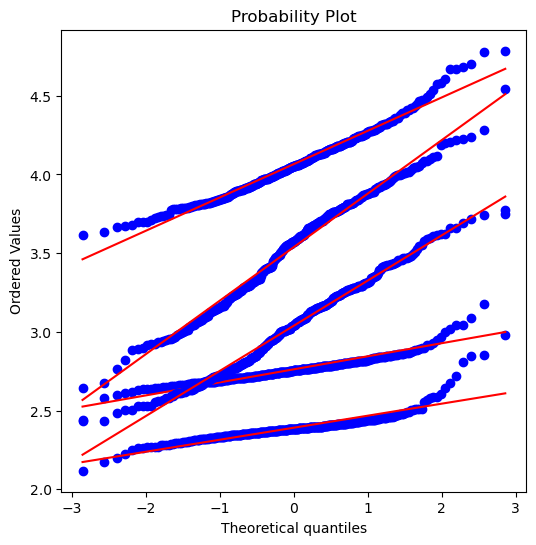

In [6]:
## QQ-plot of random columns of X_train
plt.figure(figsize=(6, 6))
for i in range(5):
    random_col = np.random.choice(X_train.shape[1])
    stats.probplot(X_train[:, random_col], dist="norm", plot=plt)

## T-test protein selection

In [7]:
rows = []
mask1 = (y_train == 1)   # ARDS
mask0 = (y_train == 0)   # non-ARDS

g1 = X_train[mask1]
g0 = X_train[mask0]

mean_diff = g1.mean(axis=0) - g0.mean(axis=0)

t_stats, pvals = stats.ttest_ind(
    g1, g0,
    axis=0,
    equal_var=False, 
    nan_policy='omit'
)

probeid = [seq_to_probeid(prot) for prot in proteins]

ttest_results = pd.DataFrame({
    "PROBEID": probeid,
    "protein_seq": proteins,
    "mean_diff": mean_diff,
    "t_stat": t_stats,
    "pval": pvals
})

ttest_results = ttest_results.merge(annot_df, on="PROBEID", how="left")

# -----------------------------
# Multiple testing correction (train-only)
# -----------------------------

significant_proteins_bool, adj_p, _, _ = multipletests(ttest_results["pval"].values, method="fdr_bh")
ttest_results["adj_p"] = adj_p

# optional: sort
ttest_results = ttest_results.sort_values(["adj_p", "pval"], ascending=True).reset_index(drop=True)

In [8]:
ttest_results.head()

,PROBEID,protein_seq,mean_diff,t_stat,pval,SYMBOL,UNIPROT,ENTREZID,GENENAME,adj_p
0,18205-123,seq.18205.123,-0.129688,-5.405266,1.646835e-07,MAGEA6,A8IF93,4105.0,MAGE family member A6,0.001775
1,26103-20,seq.26103.20,-0.073638,-5.159865,6.167584e-07,SDHAF2,A0AAQ5BH98,54949.0,succinate dehydrogenase complex assembly factor 2,0.003323
2,17813-21,seq.17813.21,-0.131765,-4.909086,2.099404e-06,BPHL,Q00306,670.0,biphenyl hydrolase like,0.007481
3,33451-35,seq.33451.35,-0.047649,-4.851525,3.300979e-06,HSF4,E5RK26,3299.0,heat shock transcription factor 4,0.007481
4,22528-1,seq.22528.1,-0.108849,-4.881727,3.471124e-06,PHF11,Q5W0A4,51131.0,PHD finger protein 11,0.007481


## Classifier 

In [9]:
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight="balanced")

pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
spw = (neg / pos) if pos > 0 else 1.0
xgb_model = XGBClassifier(random_state=42, n_estimators=100, max_depth=5, eval_metric="auc", scale_pos_weight=spw)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

In [10]:
for model in models.values():
    print(f"Training {model.__class__.__name__}...")
    model.fit(X_train[:, significant_proteins_bool], y_train)

Training LogisticRegression...
Training RandomForestClassifier...
Training XGBClassifier...



=== Logistic Regression ===
Test AUC-ROC: 0.6499
Test AUC-PR:  0.3452
Test Accuracy:0.6829
Test F1 Score:0.2778
Confusion Matrix:
[[51 18]
 [ 8  5]]
Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.74      0.80        69
        True       0.22      0.38      0.28        13

    accuracy                           0.68        82
   macro avg       0.54      0.56      0.54        82
weighted avg       0.76      0.68      0.71        82


=== Random Forest ===
Test AUC-ROC: 0.6165
Test AUC-PR:  0.2983
Test Accuracy:0.7805
Test F1 Score:0.3077
Confusion Matrix:
[[60  9]
 [ 9  4]]
Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.87      0.87        69
        True       0.31      0.31      0.31        13

    accuracy                           0.78        82
   macro avg       0.59      0.59      0.59        82
weighted avg       0.78      0.78      0.78        82


=== X

,Model,AUC-ROC,AUC-PR,Accuracy,F1
0,Logistic Regression,0.649944,0.345204,0.682927,0.277778
1,Random Forest,0.616499,0.298302,0.780488,0.307692
2,XGBoost,0.609810,0.282058,0.743902,0.160000


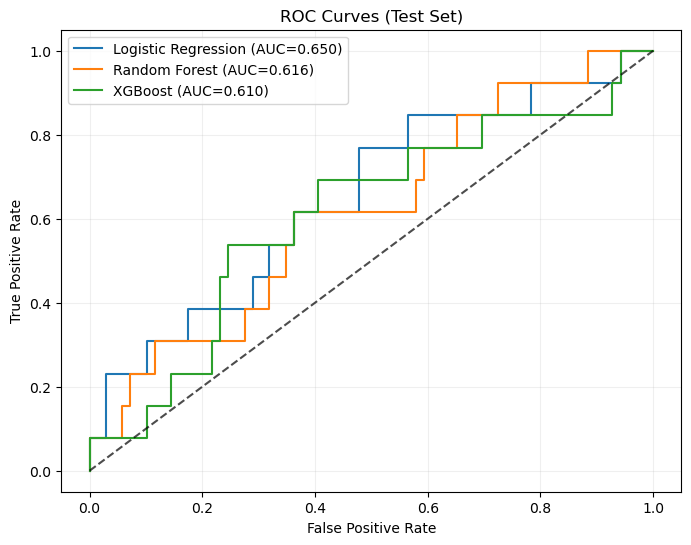

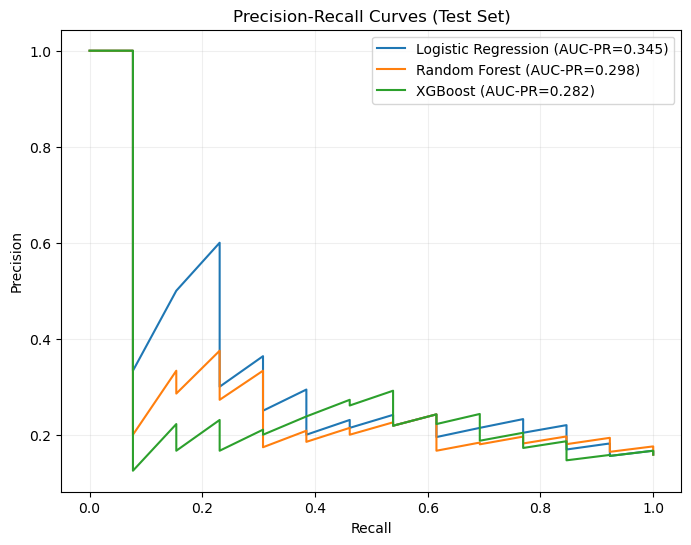

In [11]:
# Evaluate all trained models on test set + combined ROC/PR plots
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

# If you want feature subset instead, uncomment:
# X_test_eval = X_test[:, sig_proteins_idx]
X_test_eval = X_test[:, significant_proteins_bool]

summary_rows = []
roc_data = {}
pr_data = {}

for model_name, model in models.items():
    # Probabilities for positive class
    proba = model.predict_proba(X_test_eval)[:, 1]
    pred = model.predict(X_test_eval)

    auc_roc = roc_auc_score(y_test, proba)
    auc_pr = average_precision_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    summary_rows.append({
        "Model": model_name,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "Accuracy": acc,
        "F1": f1
    })

    print(f"\n=== {model_name} ===")
    print(f"Test AUC-ROC: {auc_roc:.4f}")
    print(f"Test AUC-PR:  {auc_pr:.4f}")
    print(f"Test Accuracy:{acc:.4f}")
    print(f"Test F1 Score:{f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification Report:")
    print(classification_report(y_test, pred))

    fpr, tpr, _ = roc_curve(y_test, proba)
    precision, recall, _ = precision_recall_curve(y_test, proba)

    roc_data[model_name] = (fpr, tpr, auc_roc)
    pr_data[model_name] = (recall, precision, auc_pr)

# Summary table
summary_df = pd.DataFrame(summary_rows).sort_values("AUC-ROC", ascending=False)
display(summary_df)

# Combined ROC plot
plt.figure(figsize=(8, 6))
for model_name, (fpr, tpr, auc_roc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_roc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Combined Precision-Recall plot (optional but useful)
plt.figure(figsize=(8, 6))
for model_name, (recall, precision, auc_pr) in pr_data.items():
    plt.plot(recall, precision, label=f"{model_name} (AUC-PR={auc_pr:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Test Set)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Enrichment

In [12]:
p_thres = 0.05
protein_list = ttest_results.loc[ttest_results["adj_p"] < p_thres, "SYMBOL"].dropna().unique().tolist()
background_list = ttest_results["SYMBOL"].dropna().unique().tolist()
print(f"Proteins with adj p < {p_thres}: {len(protein_list)}")
print(f"Background proteins: {len(background_list)}")

Proteins with adj p < 0.05: 20
Background proteins: 9511


In [13]:
for prot in protein_list:
    print(prot)

MAGEA6
SDHAF2
BPHL
HSF4
PHF11
ACSS2
DDC
STAT1
IL27
RGN
BLOC1S2
ALDH5A1
MAFF
AGXT
HAO1
ARID3C
DUT
COL9A1
RTF1
PABPC1


In [14]:
libs = gp.get_library_name(organism="human")
gene_sets = ["Reactome_Pathways_2024", "KEGG_2026", "GO_Biological_Process_2023"]

for gene_set_name in gene_sets:
    assert gene_set_name in libs, f"{gene_set_name} not found in gseapy libraries"


enr = gp.enrichr(
    gene_list=protein_list,
    gene_sets=gene_sets,
    organism="human",
    background=background_list,     # list of symbols
    outdir=None,             # don't write to disk; set a path if you want files
    cutoff=0.05,             # only affects plot filtering
    no_plot=True,
)

enr_results = enr.results        # pandas DataFrame, all libraries concatenated

In [18]:
reactome_lib = gp.get_library(name="Reactome_Pathways_2024", organism="Human")

In [22]:
reactome_lib["Interleukin-27 Signaling"]

['CRLF1',
 'STAT1',
 'IL27',
 'EBI3',
 'STAT3',
 'CANX',
 'IL6ST',
 'TYK2',
 'IL27RA',
 'JAK1',
 'JAK2']

In [ ]:
enr_results.head()

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,Reactome_Pathways_2024,Interleukin-27 Signaling,0.000228,0.021167,0,0,117.061728,981.468255,STAT1;IL27
1,Reactome_Pathways_2024,Glyoxylate Metabolism and Glycine Degradation,0.000323,0.021167,0,0,95.757576,769.636138,HAO1;AGXT
2,Reactome_Pathways_2024,Peroxisomal Protein Import,0.004114,0.137459,0,0,23.856061,131.052223,HAO1;AGXT
3,Reactome_Pathways_2024,Signaling by PDGF,0.004472,0.137459,0,0,22.814010,123.422136,STAT1;COL9A1
4,Reactome_Pathways_2024,Interleukin-12 Family Signaling,0.005429,0.137459,0,0,20.566449,107.275186,STAT1;IL27


In [16]:
p_thres = 0.05
bio_relevance = {}
significant_results = enr_results[enr_results["Adjusted P-value"] < p_thres]
for gene_set in enr_results["Gene_set"].unique():
    subset = significant_results[significant_results["Gene_set"] == gene_set]

    bio_relevance[gene_set] = np.sum(-np.log10(subset["Adjusted P-value"] + 1e-10))  # add small value to avoid log(0)

    print(f"Top terms for {gene_set}:")
    print(subset[["Term", "Adjusted P-value"]].head(5))
    print(f"Bio relevance score for {gene_set}: {bio_relevance[gene_set]:.4f}")
    print()

Top terms for Reactome_Pathways_2024:
                                            Term  Adjusted P-value
0                       Interleukin-27 Signaling          0.021167
1  Glyoxylate Metabolism and Glycine Degradation          0.021167
Bio relevance score for Reactome_Pathways_2024: 3.3487

Top terms for KEGG_2026:
                                        Term  Adjusted P-value
131  GLYOXYLATE AND DICARBOXYLATE METABOLISM          0.001127
Bio relevance score for KEGG_2026: 2.9482

Top terms for GO_Biological_Process_2023:
Empty DataFrame
Columns: [Term, Adjusted P-value]
Index: []
Bio relevance score for GO_Biological_Process_2023: 0.0000



# T-test iteration clustering

In [16]:
n_samples, n_features = X_train.shape
n_iterations = 1000

p_vals_matrix_tt = np.zeros((n_iterations, n_features))

for b in range(n_iterations):
    if (b+1) % 100 == 0:
        print(f"Iteration {b+1}/{n_iterations}")
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, test_size=0.5, random_state=b)

    # t-tests
    _, p_vals = stats.ttest_ind(
        X_sub[y_sub == 1], 
        X_sub[y_sub == 0], 
        axis=0, 
        equal_var=False
    )

    # mutliple testing correction
    #_, p_vals_corrected, _, _ = multipletests(p_vals, method='fdr_bh')

    p_vals_matrix_tt[b] = p_vals

Iteration 100/1000
Iteration 200/1000
Iteration 300/1000
Iteration 400/1000
Iteration 500/1000
Iteration 600/1000
Iteration 700/1000
Iteration 800/1000
Iteration 900/1000
Iteration 1000/1000


In [17]:
p_thres = 0.01
selection_matrix_tt = np.where(p_vals_matrix_tt < p_thres, 1, 0)

pi_proteins_tt = np.mean(selection_matrix_tt, axis=0)

n_selected_iteration_tt = np.sum(selection_matrix_tt, axis=1)

idx_sorted_tt = np.argsort(pi_proteins_tt)[::-1]
iter_sorted_tt = np.argsort(n_selected_iteration_tt)[::-1]


In [19]:
top_k = 100
neg_log_pvals_tt = -np.log10(p_vals_matrix_tt[:, idx_sorted_tt[:top_k]])

# L2 normalization
#norm_neg_log_pvals_tt = np.linalg.norm(neg_log_pvals_tt, axis=1, keepdims=True)
#neg_log_pvals_tt = neg_log_pvals_tt / norm_neg_log_pvals_tt

best_silhouette = -1
best_db_score = np.inf
best_k = None
for k in [2, 3, 4, 5, 6]:
    # Run KMeans clustering on p-values
    cluster_labels, _ = run_kmeans_clustering(neg_log_pvals_tt, n_clusters=k)
    silhouette_avg = silhouette_score(neg_log_pvals_tt, cluster_labels, metric="euclidean")
    davies_bouldin = davies_bouldin_score(neg_log_pvals_tt, cluster_labels)
    # Update best scores
    if silhouette_avg > best_silhouette:
        best_silhouette = silhouette_avg
        best_db_score = davies_bouldin
        best_cluster_labels = cluster_labels
        best_k = k

cluster_labels_tt, cluster_centras_tt = run_kmeans_clustering(neg_log_pvals_tt, n_clusters=best_k)
#cluster_labels_tt = run_dbscan_clustering(neg_log_pvals_tt, eps=10, min_samples=5, metric="euclidean")

silhouette_avg_tt = silhouette_score(neg_log_pvals_tt, cluster_labels_tt, metric="euclidean")
davies_bouldin_tt = davies_bouldin_score(neg_log_pvals_tt, cluster_labels_tt)

print(f"Silhouette Score: {silhouette_avg_tt:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_tt:.4f}")

print(f"Size of each cluster: {np.bincount(cluster_labels_tt)}")  # +1 to account for potential -1 in DBSCAN


c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_

Silhouette Score: 0.1789
Davies-Bouldin Index: 2.0553
Size of each cluster: [343 657]


c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


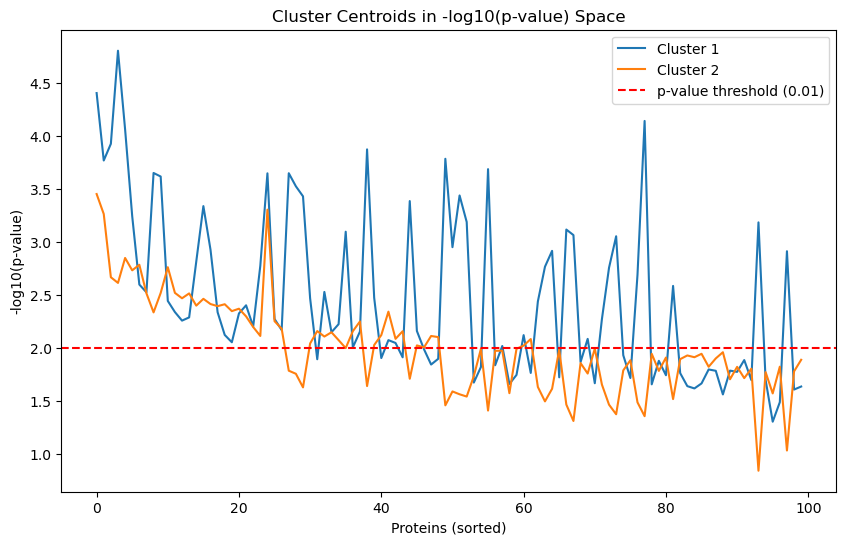

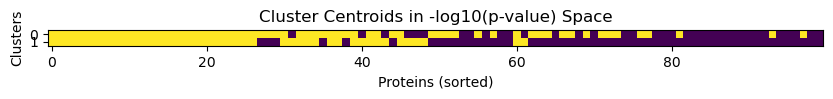

In [20]:
# plot cluster centras
plt.figure(figsize=(10, 6))
for i in range(cluster_centras_tt.shape[0]):
    plt.plot(cluster_centras_tt[i], label=f"Cluster {i+1}")
plt.axhline(-np.log10(p_thres), color='red', linestyle='--', label=f'p-value threshold ({p_thres})')
plt.xlabel("Proteins (sorted)")
plt.ylabel("-log10(p-value)")
plt.title("Cluster Centroids in -log10(p-value) Space")
plt.legend()
plt.show()

cluster_centras_sig_tt = 10**(-cluster_centras_tt) < p_thres
plt.figure(figsize=(10, 6))
plt.imshow(cluster_centras_sig_tt)
plt.xlabel("Proteins (sorted)")
plt.ylabel("Clusters")
plt.title("Cluster Centroids in -log10(p-value) Space")
plt.show()

In [21]:
protein_sets_tt = [idx_sorted_tt[:cluster_centras_sig_tt.shape[1]][cluster_centras_sig_tt[i]] for i in range(cluster_centras_sig_tt.shape[0])]

In [22]:
protein_intersection_tt = list(set(protein_sets_tt[0]).intersection(protein_sets_tt[1]))

In [23]:
# union of protein sets
protein_set_tt = set()
for i in range(cluster_centras_sig_tt.shape[0]):
    protein_set_tt.update(protein_sets_tt[i])

# convert to np array
protein_set_tt = np.array(list(protein_set_tt))

selected_proteins = [proteins[idx] for idx in protein_set_tt]
selected_proteins[:10]

['seq.7741.111',
 'seq.34860.5',
 'seq.16803.4',
 'seq.21781.9',
 'seq.17813.21',
 'seq.22528.1',
 'seq.10014.31',
 'seq.13628.58',
 'seq.21269.198',
 'seq.29456.16']

## Classifier

In [24]:
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight="balanced")

pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
spw = (neg / pos) if pos > 0 else 1.0
xgb_model = XGBClassifier(random_state=42, n_estimators=100, max_depth=5, eval_metric="auc", scale_pos_weight=spw)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

In [25]:
for model in models.values():
    print(f"Training {model.__class__.__name__}...")
    model.fit(X_train[:, protein_set_tt], y_train)

Training LogisticRegression...
Training RandomForestClassifier...
Training XGBClassifier...



=== Logistic Regression ===
Test AUC-ROC: 0.6165
Test AUC-PR:  0.3190
Test Accuracy:0.7195
Test F1 Score:0.3784
Confusion Matrix:
[[52 17]
 [ 6  7]]
Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.75      0.82        69
        True       0.29      0.54      0.38        13

    accuracy                           0.72        82
   macro avg       0.59      0.65      0.60        82
weighted avg       0.80      0.72      0.75        82


=== Random Forest ===
Test AUC-ROC: 0.6243
Test AUC-PR:  0.3242
Test Accuracy:0.8049
Test F1 Score:0.2727
Confusion Matrix:
[[63  6]
 [10  3]]
Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.91      0.89        69
        True       0.33      0.23      0.27        13

    accuracy                           0.80        82
   macro avg       0.60      0.57      0.58        82
weighted avg       0.78      0.80      0.79        82


=== X

,Model,AUC-ROC,AUC-PR,Accuracy,F1
1,Random Forest,0.624303,0.324205,0.804878,0.272727
0,Logistic Regression,0.616499,0.318998,0.719512,0.378378
2,XGBoost,0.569677,0.288397,0.780488,0.181818


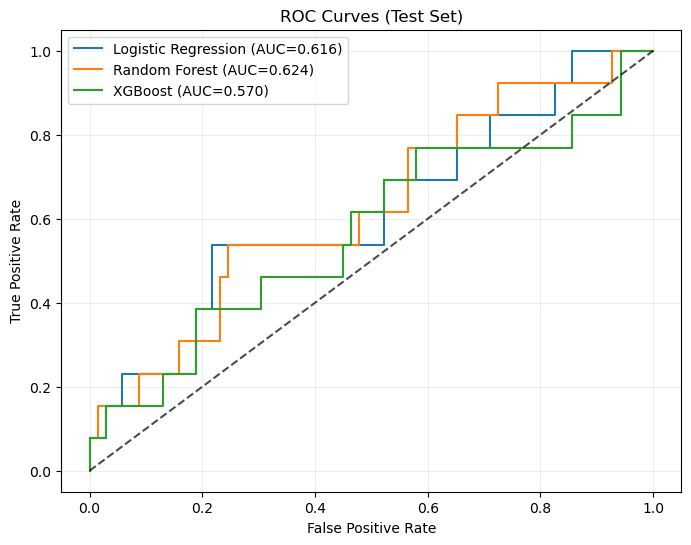

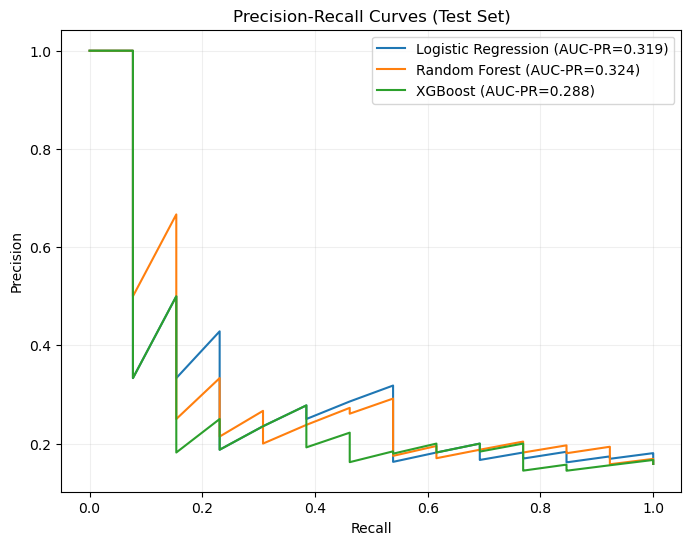

In [26]:
# If you want feature subset instead, uncomment:
# X_test_eval = X_test[:, sig_proteins_idx]
X_test_eval = X_test[:, protein_set_tt]

summary_rows = []
roc_data = {}
pr_data = {}

for model_name, model in models.items():
    # Probabilities for positive class
    proba = model.predict_proba(X_test_eval)[:, 1]
    pred = model.predict(X_test_eval)

    auc_roc = roc_auc_score(y_test, proba)
    auc_pr = average_precision_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    summary_rows.append({
        "Model": model_name,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "Accuracy": acc,
        "F1": f1
    })

    print(f"\n=== {model_name} ===")
    print(f"Test AUC-ROC: {auc_roc:.4f}")
    print(f"Test AUC-PR:  {auc_pr:.4f}")
    print(f"Test Accuracy:{acc:.4f}")
    print(f"Test F1 Score:{f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification Report:")
    print(classification_report(y_test, pred))

    fpr, tpr, _ = roc_curve(y_test, proba)
    precision, recall, _ = precision_recall_curve(y_test, proba)

    roc_data[model_name] = (fpr, tpr, auc_roc)
    pr_data[model_name] = (recall, precision, auc_pr)

# Summary table
summary_df = pd.DataFrame(summary_rows).sort_values("AUC-ROC", ascending=False)
display(summary_df)

# Combined ROC plot
plt.figure(figsize=(8, 6))
for model_name, (fpr, tpr, auc_roc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_roc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Combined Precision-Recall plot (optional but useful)
plt.figure(figsize=(8, 6))
for model_name, (recall, precision, auc_pr) in pr_data.items():
    plt.plot(recall, precision, label=f"{model_name} (AUC-PR={auc_pr:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Test Set)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Enrichment

In [27]:
probeid = [seq_to_probeid(prot) for prot in selected_proteins]
protein_sig_df = pd.DataFrame({
    "PROBEID": probeid,
    "protein": selected_proteins
})
protein_sig_df = protein_sig_df.merge(annot_df, on="PROBEID", how="left")
#protein_sig_df.head()
for row in protein_sig_df.itertuples():
    print(f"{row.SYMBOL}")

protein_list = protein_sig_df["SYMBOL"].dropna().unique().tolist()
print(len(protein_list))

RTF1
nan
CALB2
ACY3
BPHL
PHF11
SNAI2
GRB14
EPHX2
CCER2
STAT1
NOTCH2NLB
PGM1
LIPH
DUSP14
MAPK14
GPC6
CDCA3
DDC
MAFF
TEN1
ACADL
TPM3
GPD1
HNMT
ACO1
DAO
PABPC1
TKFC
ADH1B
ACSS2
PCK1
RGN
GPD1
PIPOX
GAS2
GATM
COL9A1
GRHPR
ASPA
ARID3C
HSF4
TMIE
STAT1
TLDC2
USH1C
MAGEA6
FMC1
NT5E
SEC14L2
TRIM9
MISP
DPYS
APBB1
IL27
RFX3
HAO1
LRRC15
DUT
SDHAF2
BLOC1S2
UAP1
S100A12
ESPN
CDNF
CNN1
HSPA12A
ALDH5A1
CYCS
RBM17
AGXT
68


In [28]:
libs = gp.get_library_name(organism="human")
gene_sets = ["Reactome_Pathways_2024", "KEGG_2026", "GO_Biological_Process_2023"]

for gene_set_name in gene_sets:
    assert gene_set_name in libs, f"{gene_set_name} not found in gseapy libraries"


enr = gp.enrichr(
    gene_list=protein_list,
    gene_sets=gene_sets,
    organism="human",
    background=background_list,     # list of symbols
    outdir=None,             # don't write to disk; set a path if you want files
    cutoff=0.05,             # only affects plot filtering
    no_plot=True,
)

enr_results = enr.results        # pandas DataFrame, all libraries concatenated

In [29]:
enr_results.head()

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,Reactome_Pathways_2024,Metabolism,1.429991e-07,0.000048,0,0,4.106644,64.722468,ACY3;DDC;ACSS2;ADH1B;DPYS;HNMT;BPHL;NT5E;TKFC;...
1,Reactome_Pathways_2024,Glyoxylate Metabolism and Glycine Degradation,1.627736e-06,0.000273,0,0,65.513889,873.190111,GRHPR;DAO;HAO1;AGXT
2,Reactome_Pathways_2024,Peroxisomal Protein Import,1.757963e-05,0.001963,0,0,18.199768,199.265061,DAO;EPHX2;PIPOX;HAO1;AGXT
3,Reactome_Pathways_2024,Metabolism of Amino Acids and Derivatives,2.424790e-05,0.002031,0,0,6.674271,70.928682,GRHPR;DDC;GATM;DAO;PIPOX;HAO1;HNMT;AGXT;ASPA
4,Reactome_Pathways_2024,Sensory Processing of Sound by Outer Hair Cell...,7.183303e-04,0.048128,0,0,19.764336,143.065746,TMIE;USH1C;ESPN


In [30]:
p_thres = 0.05
bio_relevance = {}
significant_results = enr_results[enr_results["Adjusted P-value"] < p_thres]
for gene_set in enr_results["Gene_set"].unique():
    subset = significant_results[significant_results["Gene_set"] == gene_set]

    bio_relevance[gene_set] = np.sum(-np.log10(subset["Adjusted P-value"] + 1e-10))  # add small value to avoid log(0)

    print(f"Top terms for {gene_set}:")
    print(subset[["Term", "Adjusted P-value"]].head(5))
    print(f"Bio relevance score for {gene_set}: {bio_relevance[gene_set]:.4f}")
    print()

Top terms for Reactome_Pathways_2024:
                                                Term  Adjusted P-value
0                                         Metabolism          0.000048
1      Glyoxylate Metabolism and Glycine Degradation          0.000273
2                         Peroxisomal Protein Import          0.001963
3          Metabolism of Amino Acids and Derivatives          0.002031
4  Sensory Processing of Sound by Outer Hair Cell...          0.048128
Bio relevance score for Reactome_Pathways_2024: 14.6010

Top terms for KEGG_2026:
                                         Term  Adjusted P-value
335   GLYOXYLATE AND DICARBOXYLATE METABOLISM          0.000102
336  GLYCINE, SERINE AND THREONINE METABOLISM          0.000116
337                                PEROXISOME          0.001202
338                       PYRUVATE METABOLISM          0.004917
339              GLYCOLYSIS / GLUCONEOGENESIS          0.015397
Bio relevance score for KEGG_2026: 16.5236

Top terms for GO_Biologica

# Mutual information

In [97]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import numpy as np, pandas as pd
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import genpareto
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed

def mi_perm_test(X, y, B=2000, tail_frac=0.05, seed=42, n_jobs=-1):
    rng = np.random.default_rng(seed)
    n, p = X.shape

    def _mi(yy):
        return mutual_info_classif(X, yy, discrete_features=False, random_state=0)

    def _one_perm(seed_b):
        rng_b = np.random.default_rng(seed_b)
        return _mi(rng_b.permutation(y))

    # 1. Observed MI + B joint label permutations
    T_obs = _mi(y).astype(np.float32)
    seeds = rng.integers(0, 2**31 - 1, size=B)
    M = np.array(Parallel(n_jobs=n_jobs, backend='loky')(
            delayed(_one_perm)(s) for s in seeds), dtype=np.float32)

    # 2. Standardisation
    mu, sd = M.mean(0), M.std(0) + 1e-12
    S_obs  = (T_obs - mu) / sd
    S_null = ((M - mu) / sd).ravel()
    N = S_null.size

    # 3. GPD tail fit
    u   = np.quantile(S_null, 1 - tail_frac)
    exc = S_null[S_null > u] - u
    xi, _, beta = genpareto.fit(exc, floc=0)
    Nu  = exc.size

    # 4. p-values
    pvals = np.empty(p)
    bulk  = S_obs <= u
    sorted_null = np.sort(S_null)
    idx = np.searchsorted(sorted_null, S_obs[bulk], side='left')
    pvals[bulk]  = (1 + (N - idx)) / (N + 1)
    pvals[~bulk] = (Nu / N) * genpareto.sf(S_obs[~bulk] - u, xi, scale=beta)
    pvals = np.clip(pvals, 1/(N+1), 1)

    # 5. BH
    _, padj, _, _ = multipletests(pvals, method='fdr_bh')
    return (pd.DataFrame({'feature': np.arange(p), 'MI': T_obs,
                          'pval': pvals, 'padj': padj})
              .sort_values('padj').reset_index(drop=True))

# usage:
# results = mi_perm_test(X, y, B=2000)
# significant = results[results.padj < 0.05]

In [62]:
mi_results = mi_perm_test(X_train, y_train, B=5, tail_frac=0.05, seed=42)

In [98]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import genpareto, spearmanr
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed

# ---------- variance prefilter (label-independent → no selection bias) ----------
def variance_prefilter(X, n_keep=750):
    v = np.nanvar(X, axis=0)
    idx = np.argsort(v)[::-1][:n_keep]
    return X[:, idx], idx

# ---------- method under test: pooled GPD ----------
def mi_perm_pooled(X, y, B=2000, tail_frac=0.05, seed=42, n_jobs=-1):
    rng = np.random.default_rng(seed)
    p = X.shape[1]
    def _mi(yy): return mutual_info_classif(X, yy, discrete_features=False, random_state=0)
    def _one(s): return _mi(np.random.default_rng(s).permutation(y))
    T_obs = _mi(y).astype(np.float32)
    seeds = rng.integers(0, 2**31-1, size=B)
    M = np.array(Parallel(n_jobs=n_jobs)(delayed(_one)(s) for s in seeds), dtype=np.float32)
    mu, sd = M.mean(0), M.std(0) + 1e-12
    S_obs  = (T_obs - mu) / sd
    S_null = ((M - mu) / sd).ravel()
    N = S_null.size
    u   = np.quantile(S_null, 1 - tail_frac)
    exc = S_null[S_null > u] - u
    xi, _, beta = genpareto.fit(exc, floc=0)
    Nu = exc.size
    pvals = np.empty(p); bulk = S_obs <= u
    sn  = np.sort(S_null)
    idx = np.searchsorted(sn, S_obs[bulk], side='left')
    pvals[bulk]  = (1 + (N - idx)) / (N + 1)
    pvals[~bulk] = (Nu / N) * genpareto.sf(S_obs[~bulk] - u, xi, scale=beta)
    pvals = np.clip(pvals, 1/(N+1), 1)
    _, padj, _, _ = multipletests(pvals, method='fdr_bh')
    return pd.DataFrame({'feature': np.arange(p), 'MI': T_obs,
                         'pval_pool': pvals, 'padj_pool': padj})

# ---------- ground truth: per-feature Besag–Clifford adaptive permutation ----------
def _adaptive_one(j, X, y, max_perm, h, seed):
    rng = np.random.default_rng(seed)
    xj = X[:, j:j+1]
    mi_obs = mutual_info_classif(xj, y, random_state=0)[0]
    hits = 0
    for b in range(1, max_perm + 1):
        if mutual_info_classif(xj, rng.permutation(y), random_state=0)[0] >= mi_obs:
            hits += 1
            if hits >= h:
                return j, mi_obs, h, b, h / b              # valid BC p-value
    return j, mi_obs, hits, max_perm, (hits + 1) / (max_perm + 1)

def mi_perm_adaptive(X, y, max_perm=100_000, h=5, seed=42, n_jobs=-1):
    p = X.shape[1]
    seeds = np.random.default_rng(seed).integers(0, 2**31-1, size=p)
    rows = Parallel(n_jobs=n_jobs)(
        delayed(_adaptive_one)(j, X, y, max_perm, h, s) for j, s in enumerate(seeds))
    df = pd.DataFrame(rows, columns=['feature','MI','hits','perm_n','pval_adapt'])
    _, padj, _, _ = multipletests(df['pval_adapt'].values, method='fdr_bh')
    df['padj_adapt'] = padj
    return df

In [111]:
# ---------- run both ----------
X_sub, kept = variance_prefilter(X, n_keep=2000)
print(f"Variance-filtered to {X_sub.shape[1]} features")

Variance-filtered to 2000 features


In [112]:
res_pool  = mi_perm_pooled  (X_sub, y, B=2000)

In [121]:
res_adapt = mi_perm_adaptive(X_sub, y, max_perm=200_000, h=5)

Spearman r (raw p):            0.922
Significant pooled / adaptive: 0 / 0
Overlap of significant sets:   0
Adaptive perms used (total):   216,843


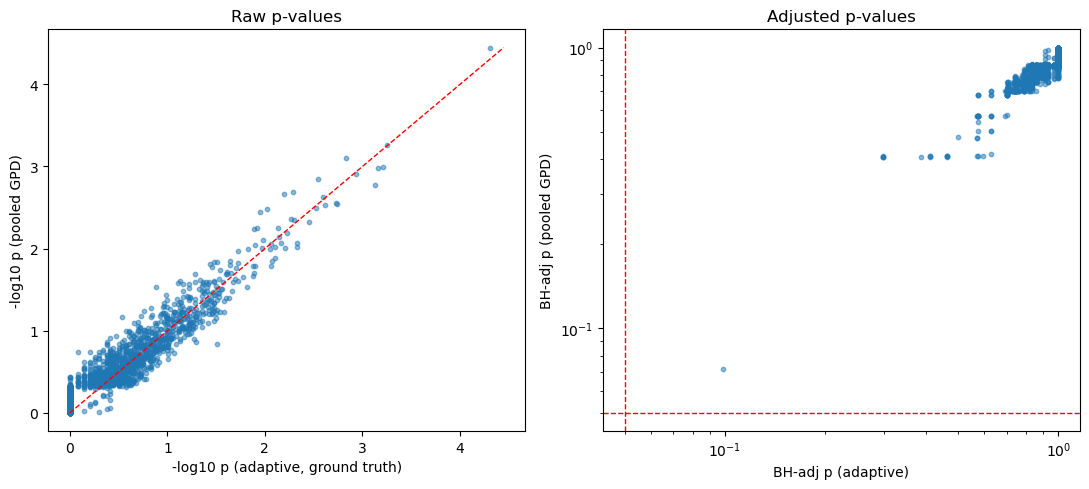

In [122]:
cmp = res_pool.merge(res_adapt[['feature','pval_adapt','padj_adapt','perm_n']], on='feature')
sig_p, sig_a = cmp.padj_pool < 0.05, cmp.padj_adapt < 0.05

print(f"Spearman r (raw p):            {spearmanr(cmp.pval_pool, cmp.pval_adapt).correlation:.3f}")
print(f"Significant pooled / adaptive: {sig_p.sum()} / {sig_a.sum()}")
print(f"Overlap of significant sets:   {(sig_p & sig_a).sum()}")
print(f"Adaptive perms used (total):   {cmp.perm_n.sum():,}")

# ---------- plots ----------
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].scatter(-np.log10(cmp.pval_adapt), -np.log10(cmp.pval_pool), s=10, alpha=0.5)
lim = float(max((-np.log10(cmp.pval_adapt)).max(), (-np.log10(cmp.pval_pool)).max()))
ax[0].plot([0, lim], [0, lim], 'r--', lw=1)
ax[0].set(xlabel='-log10 p (adaptive, ground truth)',
          ylabel='-log10 p (pooled GPD)', title='Raw p-values')

ax[1].scatter(cmp.padj_adapt, cmp.padj_pool, s=10, alpha=0.5)
ax[1].axhline(0.05, color='r', ls='--', lw=1); ax[1].axvline(0.05, color='r', ls='--', lw=1)
ax[1].set(xlabel='BH-adj p (adaptive)', ylabel='BH-adj p (pooled GPD)',
          xscale='log', yscale='log', title='Adjusted p-values')
plt.tight_layout(); plt.show()

In [123]:
res_pool["proteins_seq"] = [proteins[i] for i in res_pool["feature"]]
probeid = [seq_to_probeid(prot) for prot in res_pool["proteins_seq"]]
res_pool["PROBEID"] = probeid
res_pool.head()

,feature,MI,pval_pool,padj_pool,proteins_seq,PROBEID,SYMBOL,UNIPROT,ENTREZID,GENENAME
0,0,0.019602,0.123363,0.741915,seq.10000.28,10000-28,CRYBB2,A0A0H3W5U0,1415.0,crystallin beta B2
1,1,0.010848,0.250110,0.812164,seq.10001.7,10001-7,RAF1,A0A0S2Z559,5894.0,"Raf-1 proto-oncogene, serine/threonine kinase"
2,2,0.000000,0.590135,0.912109,seq.10003.15,10003-15,ZNF41,P51814,7592.0,zinc finger protein 41
3,3,0.021213,0.110927,0.733896,seq.10006.25,10006-25,ELK1,B2R7H4,2002.0,ETS transcription factor ELK1
4,4,0.000000,0.788320,0.969560,seq.10008.43,10008-43,GUCA1A,B2R9P6,2978.0,guanylate cyclase activator 1A


In [124]:
res_pool = res_pool.merge(annot_df, on="PROBEID", how="left")
res_pool.head()

,feature,MI,pval_pool,padj_pool,proteins_seq,PROBEID,SYMBOL_x,UNIPROT_x,ENTREZID_x,GENENAME_x,SYMBOL_y,UNIPROT_y,ENTREZID_y,GENENAME_y
0,0,0.019602,0.123363,0.741915,seq.10000.28,10000-28,CRYBB2,A0A0H3W5U0,1415.0,crystallin beta B2,CRYBB2,A0A0H3W5U0,1415.0,crystallin beta B2
1,1,0.010848,0.250110,0.812164,seq.10001.7,10001-7,RAF1,A0A0S2Z559,5894.0,"Raf-1 proto-oncogene, serine/threonine kinase",RAF1,A0A0S2Z559,5894.0,"Raf-1 proto-oncogene, serine/threonine kinase"
2,2,0.000000,0.590135,0.912109,seq.10003.15,10003-15,ZNF41,P51814,7592.0,zinc finger protein 41,ZNF41,P51814,7592.0,zinc finger protein 41
3,3,0.021213,0.110927,0.733896,seq.10006.25,10006-25,ELK1,B2R7H4,2002.0,ETS transcription factor ELK1,ELK1,B2R7H4,2002.0,ETS transcription factor ELK1
4,4,0.000000,0.788320,0.969560,seq.10008.43,10008-43,GUCA1A,B2R9P6,2978.0,guanylate cyclase activator 1A,GUCA1A,B2R9P6,2978.0,guanylate cyclase activator 1A


## Enrichment

In [125]:
p_thres = 0.05
protein_list = res_pool.loc[res_pool["padj_pool"] < p_thres, "SYMBOL"].dropna().unique().tolist()
print(f"Proteins with adj p < {p_thres}: {len(protein_list)}")
print(f"Background proteins: {len(background_list)}")

KeyError: 'SYMBOL'

In [ ]:
libs = gp.get_library_name(organism="human")
gene_sets = ["Reactome_Pathways_2024", "KEGG_2026", "GO_Biological_Process_2023"]

for gene_set_name in gene_sets:
    assert gene_set_name in libs, f"{gene_set_name} not found in gseapy libraries"


enr = gp.enrichr(
    gene_list=protein_list,
    gene_sets=gene_sets,
    organism="human",
    background=background_list,     # list of symbols
    outdir=None,             # don't write to disk; set a path if you want files
    cutoff=0.05,             # only affects plot filtering
    no_plot=True,
)

enr_results = enr.results        # pandas DataFrame, all libraries concatenated

EnrichrValidationError: Gene list cannot be empty

In [ ]:
p_thres = 0.05
bio_relevance = {}
significant_results = enr_results[enr_results["Adjusted P-value"] < p_thres]
for gene_set in enr_results["Gene_set"].unique():
    subset = significant_results[significant_results["Gene_set"] == gene_set]

    bio_relevance[gene_set] = np.sum(-np.log10(subset["Adjusted P-value"] + 1e-10))  # add small value to avoid log(0)

    print(f"Top terms for {gene_set}:")
    print(subset[["Term", "Adjusted P-value"]].head(5))
    print(f"Bio relevance score for {gene_set}: {bio_relevance[gene_set]:.4f}")
    print()

Top terms for Reactome_Pathways_2024:
                                              Term  Adjusted P-value
0  Mitochondrial Unfolded Protein Response (UPRmt)          0.007318
1                                Attenuation Phase          0.007318
2                                  HSF1 Activation          0.007318
3                                       Aggrephagy          0.007318
4                   HSF1-dependent Transactivation          0.007318
Bio relevance score for Reactome_Pathways_2024: 20.6256

Top terms for KEGG_2026:
             Term  Adjusted P-value
12  LEGIONELLOSIS          0.005152
Bio relevance score for KEGG_2026: 2.2880

Top terms for GO_Biological_Process_2023:
                                                 Term  Adjusted P-value
13  Negative Regulation Of Double-Strand Break Rep...          0.004756
14       Cellular Response To Copper Ion (GO:0071280)          0.004756
15    Regulation Of mRNA Polyadenylation (GO:1900363)          0.004756
16  Positive Regulati